In [ ]:
### from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
# <!-- Load data -->
iris = load_iris()
X = iris.data
 # <!-- Standardize features -->
X_scaled = StandardScaler().fit_transform(X)
# <!-- # Fit PCA -->
pca = PCA()
pca.fit(X_scaled)

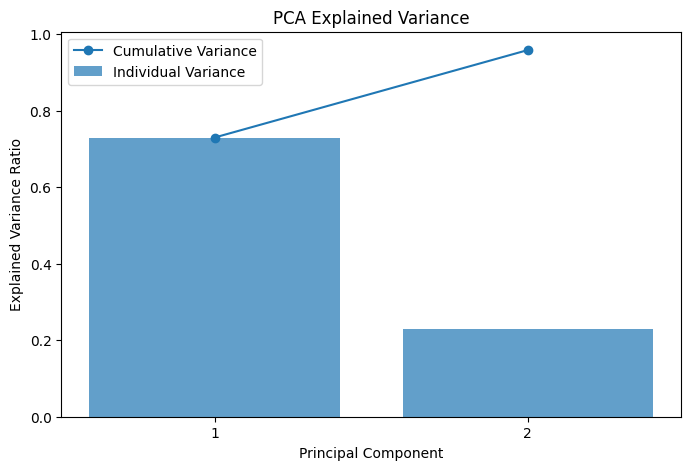

In [13]:
#Explained variance ratios
explained_variance = pca.explained_variance_ratio_
# Cumulative variance
cumulative_variance = np.cumsum(explained_variance)
# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(
    range(1, len(explained_variance) + 1),
    explained_variance,
    alpha=0.7,
    label="Individual Variance"
)

ax.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker='o',
    label="Cumulative Variance"
)

ax.set_xlabel("Principal Component")
ax.set_ylabel("Explained Variance Ratio")
ax.set_title("PCA Explained Variance")
ax.set_xticks(range(1, len(explained_variance) + 1))
ax.legend()
plt.show()

In [14]:
for i, var in enumerate(pca.explained_variance_ratio_, start=1):
    print(f"PC{i}: {var:.4f}")

print("\nCumulative:")

print(np.cumsum(pca.explained_variance_ratio_))

PC1: 0.7296
PC2: 0.2285

Cumulative:
[0.72962445 0.95813207]


In [15]:
pca = PCA(n_components=0.95)
X_reduced = pca.fit_transform(X_scaled)
print("Components chosen:", pca.n_components_)

Components chosen: 2


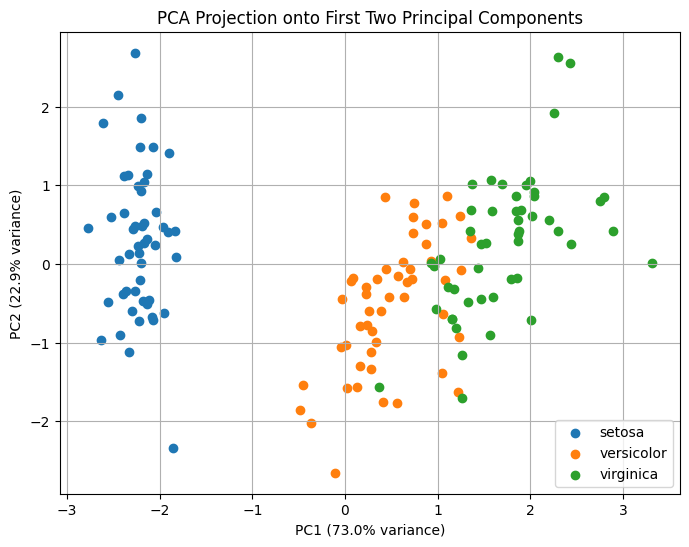

In [16]:
### Load data
iris = load_iris()

X = iris.data
y = iris.target

# Standardize
X_scaled = StandardScaler().fit_transform(X)

# Keep only first 2 principal components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
# Plot
plt.figure(figsize=(8, 6))
for species in range(3):
    plt.scatter(
        X_pca[y == species, 0],
        X_pca[y == species, 1],
        label=iris.target_names[species]
    )

plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)"
)

plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)"
)

plt.title("PCA Projection onto First Two Principal Components")
plt.legend()
plt.grid(True)
plt.show()

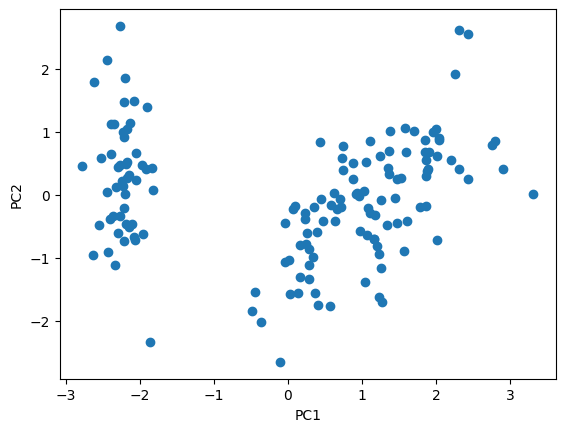

In [19]:
plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [20]:
X_pca

array([[-2.26470281,  0.4800266 ],
       [-2.08096115, -0.67413356],
       [-2.36422905, -0.34190802],
       [-2.29938422, -0.59739451],
       [-2.38984217,  0.64683538],
       [-2.07563095,  1.48917752],
       [-2.44402884,  0.0476442 ],
       [-2.23284716,  0.22314807],
       [-2.33464048, -1.11532768],
       [-2.18432817, -0.46901356],
       [-2.1663101 ,  1.04369065],
       [-2.32613087,  0.13307834],
       [-2.2184509 , -0.72867617],
       [-2.6331007 , -0.96150673],
       [-2.1987406 ,  1.86005711],
       [-2.26221453,  2.68628449],
       [-2.2075877 ,  1.48360936],
       [-2.19034951,  0.48883832],
       [-1.898572  ,  1.40501879],
       [-2.34336905,  1.12784938],
       [-1.914323  ,  0.40885571],
       [-2.20701284,  0.92412143],
       [-2.7743447 ,  0.45834367],
       [-1.81866953,  0.08555853],
       [-2.22716331,  0.13725446],
       [-1.95184633, -0.62561859],
       [-2.05115137,  0.24216355],
       [-2.16857717,  0.52714953],
       [-2.13956345,

X_pca[0] = [-2.68, 0.32],
y[0]     = 0. ------>
this is for iris flower

X_pca[51] = [0.87, -0.75],
y[51]     = 1. ---->  belongs to Versicolor

<h3>If you want to understand why PC1 and PC2 separate the data, you can also inspect the component loadings:</h3>
This tells you how much each original feature contributes to each principal component. 

In [17]:
loadings = pd.DataFrame( 
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=iris.feature_names
)

print(loadings)

                        PC1       PC2
sepal length (cm)  0.521066  0.377418
sepal width (cm)  -0.269347  0.923296
petal length (cm)  0.580413  0.024492
petal width (cm)   0.564857  0.066942
